# Longitudinal Minimal-Marker Alzheimer’s Progression Prediction

**Research question:** Using longitudinal ADNI data, what is the smallest leakage-resistant set of clinical, cognitive, FreeSurfer MRI, APOE/genetic, and optional blood biomarker features needed to accurately predict Alzheimer’s progression over a 2-year period?

This notebook replaces the old missing-data robustness framing with a diagnostic-efficiency framing:
identify the smallest high-value marker set that preserves performance while reducing testing burden.

## Cell 1 — Imports and global configuration

In [49]:
import os
import re
import json
import math
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GroupKFold
try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
except Exception:
    HAS_STRATIFIED_GROUP_KFOLD = False

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    f1_score, confusion_matrix, roc_curve, precision_recall_curve,
    brier_score_loss
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Update this path on your machine if needed.
PROJECT_DIR = Path("/Users/suvankapoor/Documents/Multimodal Alzheimer's Research")
CSV_DIR = PROJECT_DIR / "csv_exports"

# If running inside a different environment, you can override here:
if not CSV_DIR.exists():
    CSV_DIR = Path("csv_exports")

OUTPUT_DIR = PROJECT_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
PREDICTION_HORIZON_MONTHS = 24
MIN_FOLLOWUP_FOR_STABLE_MONTHS = 18

print("CSV_DIR:", CSV_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("StratifiedGroupKFold available:", HAS_STRATIFIED_GROUP_KFOLD)

CSV_DIR: /Users/suvankapoor/Documents/Multimodal Alzheimer's Research/csv_exports
OUTPUT_DIR: /Users/suvankapoor/Documents/Multimodal Alzheimer's Research/outputs
StratifiedGroupKFold available: True


## Cell 2 — File registry: required, optional, and benchmark datasets

In [50]:
CORE_FILES = [
    "ADSL", "DXSUM", "VISITS", "REGISTRY", "PTDEMOG", "RMT_PTDEMOG"
]

COGNITIVE_FILES = [
    "NEUROBAT", "NEUROEXM", "UWNPSYCHSUM",
    "MMSE", "MOCA", "CDR", "FAQ", "ADAS",
    "ECOGPT", "ECOGSP", "ECOG12PT", "ECOG12SP",
    "NPI", "NPIQ", "GDSCALE"
]

MRI_FILES = [
    "UCSFFSX6", "UCSFFSX7", "UCSFFSX", "UCSFFSL", "UCSFFSL51",
    "UCSFFSL51ALL", "UCSFFSL51Y1", "UCSFFSX51", "UCSFFSX51_ADNI1_3T",
    "UCSFSNTVOL", "UCSFASLFS_V2", "UCSFASLFSCBF", "UCSFASLQC",
    "UCSFATROPHY", "MRIMETA", "MRI3META", "MRIQC", "MRIINFQ",
    "MRIINCLUSIO", "MRI_INFARCTS"
]

GENETIC_FILES = ["APOERES", "RMT_APOERES", "GENETIC"]

BIOMARKER_FILES = [
    "UPENNBIOMK_MASTER", "UPENNBIOMK_ROCHE_ELECSYS", "UPENNBIOMKADNIDIAN2017",
    "UPENNPLASMA", "FUJIREBIOABETA", "FUJIREBIOABETAPLASMA",
    "BLENNOWPLASMANFL", "BLENNOWPLASMANFLLONG", "BLENNOWPLASMATAU",
    "BLENNOWCSFNFL", "BLENNOWCSFNG", "UGOTPTAU181",
    "C2N_PRECIVITYAD2_PLASMA", "BIOMARK", "LABDATA", "LABTESTS", "URMC_LABDATA"
]

PET_FILES = [
    "AMYDISC", "AMYMETA", "AMYQC", "AMYREAD", "AV45META", "AV45QC", "AV45FOLLOW",
    "TAUMETA", "TAUQC", "PETC3", "PETMETA_ADNI1", "PETMETA3", "PETQC",
    "PIBMETA", "PIBPETSUVR", "PIBQC",
    "UCBERKELEY_AMY_6MM", "UCBERKELEY_TAU_6MM", "UCBERKELEY_TAUPVC_6MM",
    "UCBERKELEYFDG_8mm", "BAIPETNMRC", "BAIPETNMRCAV45", "BAIPETNMRCFDG", "BAIPETNMRCFTP"
]

COVARIATE_FILES = ["VITALS", "PHYSICAL", "MEDHIST", "RECMEDS", "RECMHIST", "FAMHXPAR", "FAMHXSIB", "FHQ"]

FIRST_PASS_FILES = [
    "ADSL", "DXSUM", "VISITS", "PTDEMOG",
    "NEUROBAT", "UWNPSYCHSUM",
    "UCSFFSX6", "UCSFFSX7", "MRIMETA", "MRIQC",
    "APOERES"
]

## Cell 3 — Load CSV exports

In [51]:
def load_csv_if_exists(name, csv_dir=CSV_DIR):
    path = csv_dir / f"{name}.csv"
    if not path.exists():
        return None
    try:
        df = pd.read_csv(path, low_memory=False)
        df.columns = [str(c).strip() for c in df.columns]
        return df
    except Exception as e:
        print(f"Could not load {name}: {e}")
        return None

def load_many(names):
    out = {}
    for name in names:
        df = load_csv_if_exists(name)
        if df is not None:
            out[name] = df
            print(f"Loaded {name}: {df.shape}")
        else:
            print(f"Missing {name}.csv")
    return out

data = load_many(sorted(set(CORE_FILES + COGNITIVE_FILES + MRI_FILES + GENETIC_FILES + BIOMARKER_FILES)))
print(f"\nLoaded {len(data)} files.")

Loaded ADAS: (12868, 17)
Loaded ADSL: (5146, 55)
Loaded APOERES: (3008, 17)
Loaded BIOMARK: (13988, 66)
Loaded BLENNOWCSFNFL: (415, 9)
Loaded BLENNOWCSFNG: (415, 9)
Loaded BLENNOWPLASMANFL: (598, 10)
Loaded BLENNOWPLASMANFLLONG: (3762, 12)
Loaded BLENNOWPLASMATAU: (581, 9)
Loaded C2N_PRECIVITYAD2_PLASMA: (676, 19)
Loaded CDR: (14617, 26)
Loaded DXSUM: (15881, 42)
Loaded ECOG12PT: (1236, 32)
Loaded ECOG12SP: (1230, 29)
Loaded ECOGPT: (8093, 63)
Loaded ECOGSP: (8107, 60)
Loaded FAQ: (13272, 28)
Loaded FUJIREBIOABETA: (442, 20)
Loaded FUJIREBIOABETAPLASMA: (514, 11)
Loaded GDSCALE: (13694, 33)
Loaded GENETIC: (10109, 58)
Loaded LABDATA: (2463, 133)
Loaded LABTESTS: (5474, 22)
Loaded MMSE: (14599, 59)
Loaded MOCA: (8962, 59)
Loaded MRI3META: (9278, 43)
Missing MRIINCLUSIO.csv
Missing MRIINFQ.csv
Loaded MRIMETA: (4740, 36)
Loaded MRIQC: (90250, 26)
Loaded MRI_INFARCTS: (8593, 16)
Loaded NEUROBAT: (17622, 84)
Loaded NEUROEXM: (5752, 29)
Loaded NPI: (8225, 169)
Loaded NPIQ: (7355, 42)
Loaded 

## Cell 4 — Data audit and export

In [52]:
def audit_dataframe(name, df):
    rid_col = next((c for c in df.columns if c.upper() == "RID"), None)
    vis_col = next((c for c in df.columns if c.upper() in ["VISCODE", "VISCODE2", "VISITCODE"]), None)
    date_cols = [c for c in df.columns if "DATE" in c.upper() or c.upper() in ["EXAMDATE", "EXAMDT"]]
    return {
        "file": name,
        "rows": len(df),
        "columns": df.shape[1],
        "has_RID": rid_col is not None,
        "unique_RID": df[rid_col].nunique() if rid_col else np.nan,
        "visit_col": vis_col,
        "unique_visits": df[vis_col].nunique() if vis_col else np.nan,
        "date_cols": ", ".join(date_cols[:5]),
        "missing_pct_overall": round(df.isna().mean().mean() * 100, 2)
    }

audit = pd.DataFrame([audit_dataframe(name, df) for name, df in data.items()])
display(audit.sort_values(["has_RID", "rows"], ascending=[False, False]))
audit.to_csv(OUTPUT_DIR / "data_audit.csv", index=False)

,file,rows,columns,has_RID,unique_RID,visit_col,unique_visits,date_cols,missing_pct_overall
55,URMC_LABDATA,140434,29,True,1959.0,VISCODE,13.0,"SampleDate, RecDate, update_stamp",15.19
34,REGISTRY,28858,27,True,5062.0,VISCODE,49.0,"EXAMDATE, USERDATE, USERDATE2, update_stamp",47.33
29,NEUROBAT,17622,84,True,4784.0,VISCODE,33.0,"VISDATE, USERDATE, USERDATE2, update_stamp",40.88
11,DXSUM,15881,42,True,3788.0,VISCODE,31.0,"EXAMDATE, USERDATE, USERDATE2, update_stamp",55.76
10,CDR,14617,26,True,4397.0,VISCODE,30.0,"VISDATE, USERDATE, USERDATE2, update_stamp",16.15
23,MMSE,14599,59,True,4746.0,VISCODE,29.0,"VISDATE, MMDATE, USERDATE, USERDATE2, update_s...",24.64
3,BIOMARK,13988,66,True,3002.0,VISCODE,28.0,"EXAMDATE, BILPPADATE, BILPFLDATE, BILPSPDATE, ...",52.99
19,GDSCALE,13694,33,True,4587.0,VISCODE,29.0,"VISDATE, USERDATE, USERDATE2, update_stamp",12.78
16,FAQ,13272,28,True,3017.0,VISCODE,30.0,"VISDATE, USERDATE, USERDATE2, update_stamp",15.24
0,ADAS,12868,17,True,3025.0,VISCODE,29.0,"VISDATE, USERDATE, USERDATE2, update_stamp",19.59


## Cell 5 — Utility functions for ADNI visit alignment

In [53]:
ID_COLS = {
    "RID", "PTID", "SITEID", "VISCODE", "VISCODE2", "VISIT", "EXAMDATE", "EXAMDT",
    "USERDATE", "USERDATE2", "update_stamp", "Phase", "ORIGPROT", "COLPROT"
}

def normalize_viscode(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    if s in ["bl", "sc", "scmri", "baseline"]:
        return 0
    m = re.match(r"m(\d+)", s)
    if m:
        return int(m.group(1))
    if s.isdigit():
        return int(s)
    return np.nan

def add_visit_month(df):
    df = df.copy()
    if "VISCODE2" in df.columns:
        df["visit_month"] = df["VISCODE2"].map(normalize_viscode)
    elif "VISCODE" in df.columns:
        df["visit_month"] = df["VISCODE"].map(normalize_viscode)
    else:
        df["visit_month"] = np.nan

    date_col = next((c for c in ["EXAMDATE", "EXAMDT", "USERDATE", "USERDATE2"] if c in df.columns), None)
    if date_col:
        df["exam_date"] = pd.to_datetime(df[date_col], errors="coerce")
        baseline_date = df.groupby("RID")["exam_date"].transform("min") if "RID" in df.columns else pd.NaT
        date_month = (df["exam_date"] - baseline_date).dt.days / 30.4375
        df["visit_month"] = df["visit_month"].fillna(date_month)
    else:
        df["exam_date"] = pd.NaT
    return df

def standardize_dx_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    if s in ["CN", "NL", "NORMAL", "COGNITIVELY NORMAL", "1"]:
        return "CN"
    if s in ["MCI", "EMCI", "LMCI", "2"]:
        return "MCI"
    if s in ["AD", "DEMENTIA", "DEM", "3"]:
        return "DEM"
    if "DEMENT" in s or s == "ALZHEIMER'S DISEASE":
        return "DEM"
    return np.nan

def dx_from_dxchange(x):
    # ADNI DXCHANGE common mapping:
    # 1 CN stable, 2 MCI stable, 3 AD stable, 4 CN->MCI, 5 MCI->AD,
    # 6 CN->AD, 7 MCI->CN, 8 AD->MCI, 9 AD->CN
    if pd.isna(x):
        return np.nan
    try:
        code = int(float(x))
    except Exception:
        return np.nan
    return {
        1: "CN", 2: "MCI", 3: "DEM",
        4: "MCI", 5: "DEM", 6: "DEM",
        7: "CN", 8: "MCI", 9: "CN"
    }.get(code, np.nan)

def add_dx_column(df):
    df = df.copy()
    possible_dx_cols = ["DX", "DX_bl", "DIAGNOSIS", "DXCURREN", "DXCHANGE"]
    df["dx"] = np.nan

    for col in possible_dx_cols:
        if col in df.columns and col != "DXCHANGE":
            vals = df[col].map(standardize_dx_value)
            df["dx"] = df["dx"].fillna(vals)

    if "DXCHANGE" in df.columns:
        vals = df["DXCHANGE"].map(dx_from_dxchange)
        df["dx"] = df["dx"].fillna(vals)

    return df

def preferred_visit_key(df):
    if "VISCODE2" in df.columns:
        return "VISCODE2"
    if "VISCODE" in df.columns:
        return "VISCODE"
    return None

## Cell 6 — Build diagnosis / visit backbone

In [54]:
# Prefer DXSUM for longitudinal diagnosis. Fall back to ADSL only if needed.
if "DXSUM" in data:
    dx = data["DXSUM"].copy()
elif "ADSL" in data:
    dx = data["ADSL"].copy()
else:
    raise ValueError("Need DXSUM.csv or ADSL.csv to build diagnosis backbone.")

if "RID" not in dx.columns:
    raise ValueError("Diagnosis file does not contain RID.")

dx = add_visit_month(add_dx_column(dx))
dx = dx[["RID", "VISCODE", "VISCODE2", "visit_month", "exam_date", "dx"] + 
        [c for c in dx.columns if c not in ["RID", "VISCODE", "VISCODE2", "visit_month", "exam_date", "dx"]]]
dx = dx.dropna(subset=["RID"]).copy()
dx["RID"] = dx["RID"].astype(int)

print(dx[["RID", "VISCODE", "VISCODE2", "visit_month", "dx"]].head())
print(dx["dx"].value_counts(dropna=False))

   RID VISCODE VISCODE2  visit_month   dx
0    2      bl       bl          0.0   CN
1    3      bl       bl          0.0  DEM
2    5      bl       bl          0.0   CN
3    8      bl       bl          0.0   CN
4    7      bl       bl          0.0  DEM
dx
MCI    6565
CN     6275
DEM    2996
NaN      45
Name: count, dtype: int64


## Cell 7 — Create 2-year MCI progression labels

In [55]:
def build_mci_2yr_labels(dx_df, horizon=24, min_stable_followup=18):
    rows = []
    for rid, g in dx_df.dropna(subset=["dx", "visit_month"]).groupby("RID"):
        g = g.sort_values("visit_month").copy()
        mci_visits = g[g["dx"] == "MCI"]
        if mci_visits.empty:
            continue

        # Index = first observed MCI visit
        idx = mci_visits.iloc[0]
        idx_month = idx["visit_month"]

        future = g[g["visit_month"] > idx_month].copy()
        future["months_after_index"] = future["visit_month"] - idx_month
        window = future[(future["months_after_index"] > 0) & (future["months_after_index"] <= horizon)]

        converted = int((window["dx"] == "DEM").any())
        max_followup = future["months_after_index"].max() if len(future) else np.nan

        # Keep positive converters. For negatives, require enough follow-up to reasonably call stable.
        if converted == 1:
            label_ok = True
        else:
            label_ok = pd.notna(max_followup) and max_followup >= min_stable_followup

        if label_ok:
            rows.append({
                "RID": rid,
                "index_VISCODE": idx.get("VISCODE", np.nan),
                "index_VISCODE2": idx.get("VISCODE2", np.nan),
                "index_month": idx_month,
                "index_exam_date": idx.get("exam_date", pd.NaT),
                "y_convert_2yr": converted,
                "max_followup_after_index": max_followup,
                "n_followup_visits": len(future),
                "n_window_visits": len(window)
            })

    return pd.DataFrame(rows)

labels = build_mci_2yr_labels(dx, horizon=PREDICTION_HORIZON_MONTHS, min_stable_followup=MIN_FOLLOWUP_FOR_STABLE_MONTHS)
print(labels.shape)
display(labels.head())
print(labels["y_convert_2yr"].value_counts(dropna=False))
labels.to_csv(OUTPUT_DIR / "cohort_summary.csv", index=False)

(1029, 9)


,RID,index_VISCODE,index_VISCODE2,index_month,index_exam_date,y_convert_2yr,max_followup_after_index,n_followup_visits,n_window_visits
0,2,v11,m84,84.0,2012-10-04,0,60.0,4,1
1,4,bl,bl,0.0,2005-11-08,0,36.0,4,3
2,6,bl,bl,0.0,2005-12-01,0,36.0,5,4
3,30,bl,bl,0.0,2005-10-20,1,36.0,5,4
4,33,bl,bl,0.0,2005-12-09,0,36.0,5,4


y_convert_2yr
0    768
1    261
Name: count, dtype: int64


In [56]:
[c for c in analysis_df.columns if "VISCODE" in c or "visit" in c.lower() or "exam_date" in c.lower()][:50]

['index_VISCODE',
 'index_VISCODE2',
 'index_exam_date',
 'n_followup_visits',
 'n_window_visits',
 'VISCODE2']

In [57]:
# Clean leftover merge columns before clinical/cognitive merge
bad_merge_cols = [
    c for c in analysis_df.columns
    if c.endswith("_x") 
    or c.endswith("_y")
    or c in ["VISCODE", "VISCODE2", "VISITCODE", "visit_month", "exam_date"]
]

# Keep index_VISCODE and index_month because those are needed
bad_merge_cols = [
    c for c in bad_merge_cols
    if c not in ["index_VISCODE", "index_month"]
]

print("Dropping leftover merge columns:", bad_merge_cols[:50])
analysis_df = analysis_df.drop(columns=bad_merge_cols, errors="ignore")

# Force clean merge keys
analysis_df["RID"] = pd.to_numeric(analysis_df["RID"], errors="coerce").astype("Int64")
analysis_df["index_VISCODE"] = analysis_df["index_VISCODE"].apply(normalize_visit_value)

print("Cleaned analysis_df:", analysis_df.shape)

Dropping leftover merge columns: ['VISCODE2']
Cleaned analysis_df: (1029, 913)


## Cell 8 — Merge baseline clinical/cognitive features at index visit

In [58]:
BASE_INDEX_COLS = [
    "RID",
    "index_VISCODE",
    "index_VISCODE2",
    "index_month",
    "index_exam_date",
    "y_convert_2yr",
    "max_followup_after_index",
    "n_followup_visits",
    "n_window_visits"
]

index_cohort = analysis_df[BASE_INDEX_COLS].copy()
index_cohort = index_cohort.drop_duplicates(subset=["RID"]).reset_index(drop=True)

analysis_df = index_cohort.copy()

print("Clean index_cohort:", index_cohort.shape)
print("Reset analysis_df:", analysis_df.shape)
display(analysis_df.head())

Clean index_cohort: (1029, 9)
Reset analysis_df: (1029, 9)


,RID,index_VISCODE,index_VISCODE2,index_month,index_exam_date,y_convert_2yr,max_followup_after_index,n_followup_visits,n_window_visits
0,2,v11,m84,84.0,2012-10-04,0,60.0,4,1
1,4,bl,bl,0.0,2005-11-08,0,36.0,4,3
2,6,bl,bl,0.0,2005-12-01,0,36.0,5,4
3,30,bl,bl,0.0,2005-10-20,1,36.0,5,4
4,33,bl,bl,0.0,2005-12-09,0,36.0,5,4


In [59]:
# Cell 8 replacement: safer clinical / cognitive merge with visit-code dtype fix

FIRST_PASS_CLINICAL_FILES = [
    "PTDEMOG",
    "NEUROBAT",
    "UWNPSYCHSUM",
    "NEUROEXM",
    "GDSCALE"
]

LEAKY_BENCHMARK_FILES = [
    "MMSE",
    "MOCA",
    "CDR",
    "FAQ",
    "ADAS"
]

def normalize_visit_value(x):
    """
    Converts ADNI visit values into consistent lowercase string visit codes.
    Handles values like bl, m06, m6, 6, 6.0, 12.0.
    """
    if pd.isna(x):
        return np.nan

    s = str(x).strip().lower()

    if s in ["bl", "baseline", "sc", "scmri"]:
        return "bl"

    # If numeric-like: 0, 6, 12, 24, 6.0, etc.
    try:
        val = float(s)
        if val == 0:
            return "bl"
        if val.is_integer():
            return f"m{int(val):02d}"
    except Exception:
        pass

    # If m6, m06, m12, m024
    if s.startswith("m"):
        digits = "".join(ch for ch in s if ch.isdigit())
        if digits:
            return f"m{int(digits):02d}"

    return s

def find_visit_key(df):
    for c in ["VISCODE", "VISCODE2", "VISITCODE"]:
        if c in df.columns:
            return c
    return None

def prepare_analysis_base(base):
    base = base.copy()

    if "index_VISCODE" not in base.columns:
        raise ValueError("analysis_df must contain index_VISCODE before merging features.")

    base["RID"] = pd.to_numeric(base["RID"], errors="coerce").astype("Int64")
    base["index_VISCODE"] = base["index_VISCODE"].apply(normalize_visit_value)

    return base

def prepare_feature_table_for_merge(df, prefix):
    t = df.copy()

    if "RID" not in t.columns:
        print(f"Skipping {prefix}: no RID column")
        return None, None

    key = find_visit_key(t)

    if key is None:
        print(f"Skipping {prefix}: no VISCODE/VISCODE2/VISITCODE column")
        return None, None

    t["RID"] = pd.to_numeric(t["RID"], errors="coerce").astype("Int64")
    t[key] = t[key].apply(normalize_visit_value)

    # Drop rows without merge keys
    t = t.dropna(subset=["RID", key])

    drop_exact = {
        "VISCODE", "VISCODE2", "VISITCODE", "VISIT", "VISNUM",
        "USERDATE", "USERDATE2", "update_stamp",
        "VISDATE", "EXAMDATE", "COLDATE", "RUNDATE", "SCANDATE",
        "SITEID", "ID", "PTID", "Phase", "PHASE"
    }

    drop_contains = [
        "DATE",
        "UPDATE",
        "STAMP"
    ]

    cols_to_keep = ["RID", key]

    for col in t.columns:
        if col in ["RID", key]:
            continue

        col_upper = col.upper()

        if col_upper in {x.upper() for x in drop_exact}:
            continue

        if any(token in col_upper for token in drop_contains):
            continue

        cols_to_keep.append(col)

    t = t[cols_to_keep].copy()

    rename_map = {
        col: f"{prefix}__{col}"
        for col in t.columns
        if col not in ["RID", key]
    }
    t = t.rename(columns=rename_map)

    before = len(t)
    t = t.drop_duplicates(subset=["RID", key])
    after = len(t)

    if before != after:
        print(f"{prefix}: dropped {before - after} duplicate RID-visit rows")

    print(
        f"{prefix}: merge key={key}, "
        f"RID dtype={t['RID'].dtype}, "
        f"{key} dtype={t[key].dtype}, "
        f"sample visits={t[key].dropna().unique()[:8]}"
    )

    return t, key

def merge_on_index_visit(base, feature_df, prefix):
    base = prepare_analysis_base(base)

    # Drop any existing columns from the same file if cell is rerun
    existing_prefix_cols = [c for c in base.columns if c.startswith(f"{prefix}__")]
    if existing_prefix_cols:
        print(f"Dropping existing {prefix} columns before re-merge:", len(existing_prefix_cols))
        base = base.drop(columns=existing_prefix_cols, errors="ignore")

    t, key = prepare_feature_table_for_merge(feature_df, prefix)

    if t is None or key is None:
        return base

    # Rename right-side visit key to avoid VISCODE_x / VISCODE_y problems
    t = t.rename(columns={key: "_merge_VISCODE"})

    merged = base.merge(
        t,
        left_on=["RID", "index_VISCODE"],
        right_on=["RID", "_merge_VISCODE"],
        how="left",
        validate="one_to_one"
    )

    merged = merged.drop(columns=["_merge_VISCODE"], errors="ignore")

    print(f"Merged {prefix}: {base.shape} -> {merged.shape}")
    return merged

print("Starting analysis_df:", analysis_df.shape)

for name in FIRST_PASS_CLINICAL_FILES:
    if name in data:
        analysis_df = merge_on_index_visit(analysis_df, data[name], prefix=name)
    else:
        print(f"Missing {name}, skipping.")

print("Analysis after clinical/cognitive merge:", analysis_df.shape)
display(analysis_df.head())

Starting analysis_df: (1029, 9)
PTDEMOG: dropped 218 duplicate RID-visit rows
PTDEMOG: merge key=VISCODE, RID dtype=Int64, VISCODE dtype=object, sample visits=['bl' 'f' 'm06' 'm12' 'm24' 'm18' 'm30' 'm36']
Merged PTDEMOG: (1029, 9) -> (1029, 84)
NEUROBAT: dropped 1645 duplicate RID-visit rows
NEUROBAT: merge key=VISCODE, RID dtype=Int64, VISCODE dtype=object, sample visits=['bl' 'f' 'm06' 'm12' 'm36' 'uns1' 'm18' 'm24']
Merged NEUROBAT: (1029, 84) -> (1029, 158)
UWNPSYCHSUM: merge key=VISCODE, RID dtype=Int64, VISCODE dtype=object, sample visits=['bl' 'm06' 'm36' 'm60' 'v06' 'v11' 'v21' 'v41']
Merged UWNPSYCHSUM: (1029, 158) -> (1029, 165)
NEUROEXM: merge key=VISCODE, RID dtype=Int64, VISCODE dtype=object, sample visits=['bl' 'f' 'm48' 'm36' 'm60' 'v01' '4_sc' '4_init']
Merged NEUROEXM: (1029, 165) -> (1029, 184)
GDSCALE: merge key=VISCODE, RID dtype=Int64, VISCODE dtype=object, sample visits=['bl' 'f' 'm12' 'uns1' 'm24' 'm36' 'm48' 'm72']
Merged GDSCALE: (1029, 184) -> (1029, 207)
Ana

,RID,index_VISCODE,index_VISCODE2,index_month,index_exam_date,y_convert_2yr,max_followup_after_index,n_followup_visits,n_window_visits,PTDEMOG__ORIGPROT,...,GDSCALE__GDMEMORY,GDSCALE__GDALIVE,GDSCALE__GDWORTH,GDSCALE__GDENERGY,GDSCALE__GDHOPE,GDSCALE__GDBETTER,GDSCALE__GDTOTAL,GDSCALE__DD_CRF_VERSION_LABEL,GDSCALE__LANGUAGE_CODE,GDSCALE__HAS_QC_ERROR
0,2,v11,m84,84.0,2012-10-04,0,60.0,4,1,NaN,...,No(0),Yes(0),No(0),No(1),No(0),No(0),2.0,NaN,NaN,NaN
1,4,bl,bl,0.0,2005-11-08,0,36.0,4,3,ADNI1,...,No(0),Yes(0),Yes(1),Yes(0),No(0),No(0),3.0,NaN,NaN,NaN
2,6,bl,bl,0.0,2005-12-01,0,36.0,5,4,ADNI1,...,No(0),Yes(0),No(0),Yes(0),No(0),No(0),0.0,NaN,NaN,NaN
3,30,bl,bl,0.0,2005-10-20,1,36.0,5,4,ADNI1,...,No(0),Yes(0),No(0),Yes(0),No(0),No(0),1.0,NaN,NaN,NaN
4,33,bl,bl,0.0,2005-12-09,0,36.0,5,4,ADNI1,...,Yes(1),Yes(0),No(0),Yes(0),No(0),No(0),2.0,NaN,NaN,NaN


In [60]:
suffix_cols = [c for c in analysis_df.columns if c.endswith("_x") or c.endswith("_y")]
print("Suffix columns:", len(suffix_cols))
print("Rows:", len(analysis_df))
print("Unique RIDs:", analysis_df["RID"].nunique())
print("Duplicate RIDs:", analysis_df["RID"].duplicated().sum())

Suffix columns: 0
Rows: 1029
Unique RIDs: 1029
Duplicate RIDs: 0


In [61]:
analysis_clinical = analysis_df.copy()

metadata_terms = [
    "DD_CRF", "VERSION", "LANGUAGE", "QC_ERROR", "ORIGPROT",
    "USERDATE", "UPDATE", "STAMP", "SITEID", "PTID", "VISDATE",
    "EXAMDATE", "RUNDATE", "COLDATE"
]

metadata_cols = [
    c for c in analysis_clinical.columns
    if any(term.lower() in c.lower() for term in metadata_terms)
]

print("Dropping metadata columns:", len(metadata_cols))
print(metadata_cols[:40])

analysis_clinical = analysis_clinical.drop(columns=metadata_cols, errors="ignore")
print("Clean clinical analysis shape:", analysis_clinical.shape)

Dropping metadata columns: 18
['PTDEMOG__ORIGPROT', 'PTDEMOG__PTIDENT', 'PTDEMOG__DD_CRF_VERSION_LABEL', 'PTDEMOG__LANGUAGE_CODE', 'PTDEMOG__HAS_QC_ERROR', 'NEUROBAT__ORIGPROT', 'NEUROBAT__DD_CRF_VERSION_LABEL', 'NEUROBAT__LANGUAGE_CODE', 'NEUROBAT__HAS_QC_ERROR', 'UWNPSYCHSUM__ORIGPROT', 'NEUROEXM__ORIGPROT', 'NEUROEXM__DD_CRF_VERSION_LABEL', 'NEUROEXM__LANGUAGE_CODE', 'NEUROEXM__HAS_QC_ERROR', 'GDSCALE__ORIGPROT', 'GDSCALE__DD_CRF_VERSION_LABEL', 'GDSCALE__LANGUAGE_CODE', 'GDSCALE__HAS_QC_ERROR']
Clean clinical analysis shape: (1029, 189)


## Cell 9 — Add APOE / genetics

In [62]:
def add_apoe_features(base, data):
    out = base.copy()
    for name in ["APOERES", "RMT_APOERES", "GENETIC"]:
        if name not in data or "RID" not in data[name].columns:
            continue
        t = data[name].copy()
        t["RID"] = pd.to_numeric(t["RID"], errors="coerce")
        t = t.dropna(subset=["RID"])
        t["RID"] = t["RID"].astype(int)

        # Keep one row per RID for genetics.
        t = t.sort_values("RID").drop_duplicates("RID", keep="first")
        t = clean_feature_cols(t, prefix=name)
        out = out.merge(t, on="RID", how="left")

    # Create a generic APOE4 feature if any APOE-like columns exist.
    apoe_cols = [c for c in out.columns if "APOE" in c.upper()]
    for c in apoe_cols:
        if "4" in c.upper() or "GENOTYPE" in c.upper() or "GENOTYP" in c.upper():
            # This is a best-effort parser. Inspect output before relying on it.
            pass
    return out

analysis_df = add_apoe_features(analysis_df, data)
print("Analysis after APOE merge:", analysis_df.shape)

Analysis after APOE merge: (1029, 266)


## Cell 10 — Add FreeSurfer MRI features at index visit

In [63]:
# Cell 10 — Add MRI / FreeSurfer features safely

MRI_FILES_FIRST_PASS = [
    "UCSFFSX6",
    "UCSFFSX7"
]

def prepare_mri_table_for_merge(df, prefix):
    t = df.copy()

    if "RID" not in t.columns:
        print(f"Skipping {prefix}: no RID column")
        return None

    key = find_visit_key(t)

    if key is None:
        print(f"Skipping {prefix}: no VISCODE/VISCODE2/VISITCODE column")
        return None

    t["RID"] = pd.to_numeric(t["RID"], errors="coerce").astype("Int64")
    t["_merge_VISCODE"] = t[key].apply(normalize_visit_value)

    t = t.dropna(subset=["RID", "_merge_VISCODE"])

    # Drop metadata / non-feature columns
    drop_exact = {
        "RID", "VISCODE", "VISCODE2", "VISITCODE", "VISIT", "VISNUM",
        "USERDATE", "USERDATE2", "update_stamp",
        "EXAMDATE", "RUNDATE", "SCANDATE", "SITEID", "ID", "PTID",
        "IMAGEUID", "LONIUID", "SERIESID", "EXAMID"
    }

    drop_contains = [
        "DATE",
        "UPDATE",
        "STAMP",
        "QC",
        "VERSION"
    ]

    feature_cols = []

    for col in t.columns:
        if col in ["RID", "_merge_VISCODE"]:
            continue

        col_upper = col.upper()

        if col_upper in {x.upper() for x in drop_exact}:
            continue

        if any(token in col_upper for token in drop_contains):
            continue

        # Keep mostly numeric MRI biomarkers
        if pd.api.types.is_numeric_dtype(t[col]):
            feature_cols.append(col)

    keep_cols = ["RID", "_merge_VISCODE"] + feature_cols
    t = t[keep_cols].copy()

    rename_map = {
        col: f"{prefix}__{col}"
        for col in feature_cols
    }

    t = t.rename(columns=rename_map)

    before = len(t)
    t = t.drop_duplicates(subset=["RID", "_merge_VISCODE"])
    after = len(t)

    if before != after:
        print(f"{prefix}: dropped {before - after} duplicate RID-visit MRI rows")

    print(
        f"{prefix}: prepared {t.shape[0]} rows, {t.shape[1]} columns, "
        f"sample visits={t['_merge_VISCODE'].dropna().unique()[:8]}"
    )

    return t

def add_mri_features(base, data):
    out = base.copy()

    # Clean old MRI columns if rerunning this cell
    for prefix in MRI_FILES_FIRST_PASS:
        old_cols = [c for c in out.columns if c.startswith(f"{prefix}__")]
        if old_cols:
            print(f"Dropping existing {prefix} columns before re-merge:", len(old_cols))
            out = out.drop(columns=old_cols, errors="ignore")

    out["RID"] = pd.to_numeric(out["RID"], errors="coerce").astype("Int64")
    out["index_VISCODE"] = out["index_VISCODE"].apply(normalize_visit_value)

    for name in MRI_FILES_FIRST_PASS:
        if name not in data:
            print(f"Missing {name}, skipping.")
            continue

        mri = prepare_mri_table_for_merge(data[name], prefix=name)

        if mri is None:
            continue

        before_shape = out.shape

        out = out.merge(
            mri,
            left_on=["RID", "index_VISCODE"],
            right_on=["RID", "_merge_VISCODE"],
            how="left",
            validate="one_to_one"
        )

        out = out.drop(columns=["_merge_VISCODE"], errors="ignore")

        print(f"Merged {name}: {before_shape} -> {out.shape}")

    return out

analysis_df = add_mri_features(analysis_df, data)

print("Analysis after MRI merge:", analysis_df.shape)

mri_cols = [
    c for c in analysis_df.columns
    if c.startswith("UCSFFSX6__") or c.startswith("UCSFFSX7__")
]

print("MRI columns added:", len(mri_cols))
print("MRI non-missing rows:", analysis_df[mri_cols].notna().any(axis=1).sum())

display(analysis_df.head())

UCSFFSX6: dropped 3 duplicate RID-visit MRI rows
UCSFFSX6: prepared 2267 rows, 327 columns, sample visits=['init' 'y1' 'y2' 'bl' 'y4' 'y3' 'y5']
Merged UCSFFSX6: (1029, 266) -> (1029, 591)
UCSFFSX7: dropped 849 duplicate RID-visit MRI rows
UCSFFSX7: prepared 11302 rows, 327 columns, sample visits=['init' 'v02' 'v11' 'v21' 'v04' 'v05' 'y4' 'y1']
Merged UCSFFSX7: (1029, 591) -> (1029, 916)
Analysis after MRI merge: (1029, 916)
MRI columns added: 650
MRI non-missing rows: 699


,RID,index_VISCODE,index_VISCODE2,index_month,index_exam_date,y_convert_2yr,max_followup_after_index,n_followup_visits,n_window_visits,PTDEMOG__ORIGPROT,...,UCSFFSX7__ST9SV,UCSFFSX7__ST147SV,UCSFFSX7__ST148SV,UCSFFSX7__ST149SV,UCSFFSX7__ST150SV,UCSFFSX7__ST151SV,UCSFFSX7__ST152SV,UCSFFSX7__ST153SV,UCSFFSX7__ST154SV,UCSFFSX7__ST155SV
0,2,v11,m84,84.0,2012-10-04,0,60.0,4,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,bl,bl,0.0,2005-11-08,0,36.0,4,3,ADNI1,...,1356.8,219891.188609,219663.848671,439555.037280,275938.5,276293.5,552232.0,51593.0,597673.037280,1089550.0
2,6,bl,bl,0.0,2005-12-01,0,36.0,5,4,ADNI1,...,1187.3,195616.865344,193978.344657,389595.210002,209356.5,201964.5,411321.0,43963.0,530102.210002,892212.0
3,30,bl,bl,0.0,2005-10-20,1,36.0,5,4,ADNI1,...,1405.8,205757.810731,204493.110354,410250.921085,249389.0,244191.0,493580.0,49046.0,549688.921085,980106.0
4,33,bl,bl,0.0,2005-12-09,0,36.0,5,4,ADNI1,...,2078.9,200962.241965,213531.540758,414493.782724,231012.0,232933.0,463945.0,49675.0,588902.782724,970241.0


In [64]:
suffix_cols = [c for c in analysis_df.columns if c.endswith("_x") or c.endswith("_y")]
print("Suffix columns:", len(suffix_cols))
print(suffix_cols)

analysis_df = analysis_df.drop(columns=suffix_cols, errors="ignore")

print("After dropping suffix columns:", analysis_df.shape)

print("Rows:", len(analysis_df))
print("Unique RIDs:", analysis_df["RID"].nunique())
print("Duplicate RIDs:", analysis_df["RID"].duplicated().sum())

mri_cols = [
    c for c in analysis_df.columns
    if c.startswith("UCSFFSX6__") or c.startswith("UCSFFSX7__")
]

print("MRI columns:", len(mri_cols))
print("MRI non-missing rows:", analysis_df[mri_cols].notna().any(axis=1).sum())

analysis_model = analysis_df.copy()

metadata_terms = [
    "DD_CRF", "VERSION", "LANGUAGE", "QC_ERROR", "ORIGPROT",
    "USERDATE", "UPDATE", "STAMP", "SITEID", "PTID", "VISDATE",
    "EXAMDATE", "RUNDATE", "COLDATE", "VISCODE2", "index_exam_date"
]

metadata_cols = [
    c for c in analysis_model.columns
    if any(term.lower() in c.lower() for term in metadata_terms)
]

print("Dropping metadata columns:", len(metadata_cols))
analysis_model = analysis_model.drop(columns=metadata_cols, errors="ignore")

print("Clean model shape:", analysis_model.shape)

Suffix columns: 2
['VISCODE_x', 'VISCODE_y']
After dropping suffix columns: (1029, 914)
Rows: 1029
Unique RIDs: 1029
Duplicate RIDs: 0
MRI columns: 650
MRI non-missing rows: 699
Dropping metadata columns: 25
Clean model shape: (1029, 889)


## Cell 11 — Optional: add blood / plasma / CSF biomarkers

In [65]:
USE_BIOMARKERS = False  # Change to True after clinical + MRI pipeline is working.

BIOMARKER_PATTERNS = ["PTAU", "TAU", "ABETA", "ABETA42", "ABETA40", "NFL", "GFAP", "PLASMA", "CSF"]

def add_biomarker_features(base, data, biomarker_files=BIOMARKER_FILES):
    out = base.copy()
    for name in biomarker_files:
        if name not in data or "RID" not in data[name].columns:
            continue
        t = data[name].copy()
        t["RID"] = pd.to_numeric(t["RID"], errors="coerce")
        t = t.dropna(subset=["RID"])
        t["RID"] = t["RID"].astype(int)
        t = add_visit_month(t)

        keep = [c for c in t.columns if c in ["RID", "VISCODE", "VISCODE2", "visit_month", "exam_date", "EXAMDATE", "EXAMDT"]]
        biomarker_cols = [
            c for c in t.columns
            if any(p in c.upper() for p in BIOMARKER_PATTERNS)
            and c not in keep
        ]

        if not biomarker_cols:
            continue

        t = t[keep + biomarker_cols].copy()
        t = t.rename(columns={c: f"{name}__{c}" for c in biomarker_cols})

        key = preferred_visit_key(t)
        if key and f"index_{key}" in out.columns:
            out = out.merge(t, left_on=["RID", f"index_{key}"], right_on=["RID", key], how="left")
        else:
            merged = out.merge(t, on="RID", how="left")
            if "visit_month" in merged.columns:
                merged["_bio_month_diff"] = (merged["visit_month"] - merged["index_month"]).abs()
                merged = merged[merged["_bio_month_diff"].isna() | (merged["_bio_month_diff"] <= 6)]
                merged = merged.sort_values(["RID", "_bio_month_diff"]).drop_duplicates("RID", keep="first")
                merged = merged.drop(columns=["_bio_month_diff"])
            out = merged
    return out

if USE_BIOMARKERS:
    analysis_df = add_biomarker_features(analysis_df, data)
    print("Analysis after biomarker merge:", analysis_df.shape)
else:
    print("Skipping biomarkers for first pass.")

Skipping biomarkers for first pass.


## Cell 12 — Define leakage-resistant feature groups

In [66]:
# Cell 12 — Strict feature group definitions and leakage cleanup

TARGET_COL = "y_convert_2yr"

ID_COLS = [
    "RID",
    "index_VISCODE",
    "index_VISCODE2",
    "index_month",
    "index_exam_date",
    "max_followup_after_index",
    "n_followup_visits",
    "n_window_visits"
]

# Diagnosis-adjacent / outcome-leaking terms to exclude from primary model
LEAKY_TERMS = [
    "MMSE", "MOCA", "CDR", "FAQ", "ADAS",
    "DX", "DIAG", "CONVERT", "DEMENTIA", "y_convert"
]

# Admin / metadata terms to exclude from all feature sets
METADATA_TERMS = [
    "ID", "RECNO", "ORIGPROT", "COLPROT", "SITE", "PTID",
    "DATE", "TIME", "USERDATE", "UPDATE", "STAMP",
    "VISDATE", "EXAMDATE", "RUNDATE", "COLDATE",
    "VERSION", "LANGUAGE", "QC", "ERROR",
    "SOURCE", "PHASE"
]

def is_bad_feature(col):
    col_upper = col.upper()

    if col in ID_COLS or col == TARGET_COL:
        return True

    if any(term.upper() in col_upper for term in LEAKY_TERMS):
        return True

    if any(term.upper() in col_upper for term in METADATA_TERMS):
        return True

    return False

# MRI group: ONLY FreeSurfer MRI columns
mri_cols = [
    c for c in analysis_model.columns
    if (
        c.startswith("UCSFFSX6__")
        or c.startswith("UCSFFSX7__")
    )
    and not is_bad_feature(c)
]

# APOE / genetic group: keep only actual genotype-style variables
genetic_cols = [
    c for c in analysis_model.columns
    if (
        c.startswith("APOERES__")
        or c.startswith("GENETIC__")
    )
    and not is_bad_feature(c)
    and (
        "GENOTYPE" in c.upper()
        or "APOE" in c.upper()
        or "APGEN" in c.upper()
        or "APRES" in c.upper()
    )
]

# Prefer APOERES__GENOTYPE only if available
genotype_cols = [c for c in genetic_cols if "GENOTYPE" in c.upper()]
if genotype_cols:
    genetic_cols = genotype_cols

# Clinical / cognitive group
clinical_prefixes = [
    "PTDEMOG__",
    "NEUROBAT__",
    "UWNPSYCHSUM__",
    "NEUROEXM__",
    "GDSCALE__"
]

clinical_cols = [
    c for c in analysis_model.columns
    if any(c.startswith(prefix) for prefix in clinical_prefixes)
    and not is_bad_feature(c)
]

# Limit demographics to useful low-burden variables
allowed_ptdemog_terms = [
    "PTGENDER",
    "PTEDUCAT",
    "PTHAND",
    "PTMARRY",
    "PTETHCAT",
    "PTRACCAT"
]

clinical_cols = [
    c for c in clinical_cols
    if not c.startswith("PTDEMOG__")
    or any(term in c.upper() for term in allowed_ptdemog_terms)
]

# Blood biomarkers: may be empty until biomarker files are merged
blood_prefix_terms = [
    "UPENN",
    "BLENNOW",
    "UGOT",
    "FUJIREBIO",
    "C2N",
    "BIOMARK"
]

blood_cols = [
    c for c in analysis_model.columns
    if any(term in c.upper() for term in blood_prefix_terms)
    and not is_bad_feature(c)
]

# Remove duplicates while preserving order
def unique_keep_order(cols):
    seen = set()
    out = []
    for c in cols:
        if c not in seen:
            seen.add(c)
            out.append(c)
    return out

clinical_cols = unique_keep_order(clinical_cols)
mri_cols = unique_keep_order(mri_cols)
genetic_cols = unique_keep_order(genetic_cols)
blood_cols = unique_keep_order(blood_cols)

print("clinical", len(clinical_cols))
print(clinical_cols[:30])

print("\nmri", len(mri_cols))
print(mri_cols[:30])

print("\ngenetic", len(genetic_cols))
print(genetic_cols[:30])

print("\nblood", len(blood_cols))
print(blood_cols[:30])

clinical 108
['PTDEMOG__PTGENDER', 'PTDEMOG__PTHAND', 'PTDEMOG__PTMARRY', 'PTDEMOG__PTEDUCAT', 'PTDEMOG__PTETHCAT', 'PTDEMOG__PTRACCAT', 'PTDEMOG__PTETHCATH', 'NEUROBAT__CLOCKCIRC', 'NEUROBAT__CLOCKSYM', 'NEUROBAT__CLOCKNUM', 'NEUROBAT__CLOCKHAND', 'NEUROBAT__CLOCKSCOR', 'NEUROBAT__COPYCIRC', 'NEUROBAT__COPYSYM', 'NEUROBAT__COPYNUM', 'NEUROBAT__COPYHAND', 'NEUROBAT__COPYSCOR', 'NEUROBAT__LMSTORY', 'NEUROBAT__LIMMTOTAL', 'NEUROBAT__LIMMEND', 'NEUROBAT__AVTOT1', 'NEUROBAT__AVERR1', 'NEUROBAT__AVTOT2', 'NEUROBAT__AVERR2', 'NEUROBAT__AVTOT3', 'NEUROBAT__AVERR3', 'NEUROBAT__AVTOT4', 'NEUROBAT__AVERR4', 'NEUROBAT__AVTOT5', 'NEUROBAT__AVERR5']

mri 650
['UCSFFSX6__ST101SV', 'UCSFFSX6__ST102CV', 'UCSFFSX6__ST102SA', 'UCSFFSX6__ST102TA', 'UCSFFSX6__ST102TS', 'UCSFFSX6__ST103CV', 'UCSFFSX6__ST103SA', 'UCSFFSX6__ST103TA', 'UCSFFSX6__ST103TS', 'UCSFFSX6__ST104CV', 'UCSFFSX6__ST104SA', 'UCSFFSX6__ST104TA', 'UCSFFSX6__ST104TS', 'UCSFFSX6__ST105CV', 'UCSFFSX6__ST105SA', 'UCSFFSX6__ST105TA', 'UCSFFSX6

## Cell 13 — Build modeling dataset

In [67]:
# Cell 13 — Build modeling feature sets

feature_sets = {
    "clinical_only": clinical_cols,
    "mri_only": mri_cols,
    "genetic_only": genetic_cols,
    "clinical_genetic": clinical_cols + genetic_cols,
    "clinical_mri": clinical_cols + mri_cols,
    "clinical_genetic_mri": clinical_cols + genetic_cols + mri_cols,
}

# Add blood-based feature sets only if blood biomarker columns exist
if len(blood_cols) > 0:
    feature_sets.update({
        "blood_only": blood_cols,
        "clinical_blood": clinical_cols + blood_cols,
        "clinical_genetic_blood": clinical_cols + genetic_cols + blood_cols,
        "clinical_mri_blood": clinical_cols + mri_cols + blood_cols,
        "clinical_genetic_mri_blood": clinical_cols + genetic_cols + mri_cols + blood_cols,
    })

# Clean each feature set
for name in list(feature_sets.keys()):
    cols = feature_sets[name]

    # Keep only columns that exist
    cols = [c for c in cols if c in analysis_model.columns]

    # Remove duplicates
    cols = unique_keep_order(cols)

    feature_sets[name] = cols

print("Feature set summary:")
for name, cols in feature_sets.items():
    if len(cols) == 0:
        print(f"{name}: 0 features")
        continue

    non_missing_rows = analysis_model[cols].notna().any(axis=1).sum()

    print(
        f"{name}: {len(cols)} features, "
        f"{non_missing_rows}/{len(analysis_model)} rows with at least one non-missing feature"
    )

# Define target and groups for patient-level cross-validation
y = analysis_model[TARGET_COL].astype(int)
groups = analysis_model["RID"]

print("\nTarget distribution:")
print(y.value_counts())

print("\nGroups:")
print("Unique RIDs:", groups.nunique())
print("Total rows:", len(groups))

Feature set summary:
clinical_only: 108 features, 1029/1029 rows with at least one non-missing feature
mri_only: 650 features, 699/1029 rows with at least one non-missing feature
genetic_only: 1 features, 1028/1029 rows with at least one non-missing feature
clinical_genetic: 109 features, 1029/1029 rows with at least one non-missing feature
clinical_mri: 758 features, 1029/1029 rows with at least one non-missing feature
clinical_genetic_mri: 759 features, 1029/1029 rows with at least one non-missing feature

Target distribution:
y_convert_2yr
0    768
1    261
Name: count, dtype: int64

Groups:
Unique RIDs: 1029
Total rows: 1029


## Cell 14 — Cross-validation evaluator

In [79]:
# Cell 14 — Baseline grouped cross-validation models

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np
import pandas as pd

# Patch build_preprocessor to preserve empty/all-missing features where possible

def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    transformers = []

    if len(numeric_cols) > 0:
        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("scaler", StandardScaler())
        ])
        transformers.append(("num", numeric_transformer, numeric_cols))

    if len(categorical_cols) > 0:
        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing", keep_empty_features=True)),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])
        transformers.append(("cat", categorical_transformer, categorical_cols))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )

    return preprocessor

def evaluate_model_cv(model, X, y, groups, model_name, feature_set_name, n_splits=5):
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

    rows = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        pipe = Pipeline(steps=[
            ("preprocess", build_preprocessor(X_train)),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)

        if hasattr(pipe.named_steps["model"], "predict_proba"):
            y_score = pipe.predict_proba(X_test)[:, 1]
        else:
            y_score = pipe.decision_function(X_test)

        y_pred = (y_score >= 0.5).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        youden_j = sensitivity + specificity - 1

        rows.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "fold": fold,
            "n_features": X.shape[1],
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "roc_auc": roc_auc_score(y_test, y_score),
            "pr_auc": average_precision_score(y_test, y_score),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall_sensitivity": sensitivity,
            "specificity": specificity,
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "youden_j": youden_j,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp
        })

    return pd.DataFrame(rows)

models = {
    "logistic_l2": LogisticRegression(
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ),
    "logistic_l1": LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "extra_trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

baseline_results = []

for feature_set_name, cols in feature_sets.items():
    if len(cols) == 0:
        continue

    X = analysis_model[cols].copy()

    print(f"\nRunning feature set: {feature_set_name} | {X.shape[1]} features")

    for model_name, model in models.items():
        print(f"  Model: {model_name}")

        result = evaluate_model_cv(
            model=model,
            X=X,
            y=y,
            groups=groups,
            model_name=model_name,
            feature_set_name=feature_set_name,
            n_splits=5
        )

        baseline_results.append(result)

baseline_results = pd.concat(baseline_results, ignore_index=True)

summary = (
    baseline_results
    .groupby(["feature_set", "model"])
    .agg(
        mean_auc=("roc_auc", "mean"),
        std_auc=("roc_auc", "std"),
        mean_pr_auc=("pr_auc", "mean"),
        mean_bal_acc=("balanced_accuracy", "mean"),
        mean_sensitivity=("recall_sensitivity", "mean"),
        mean_specificity=("specificity", "mean"),
        mean_youden_j=("youden_j", "mean")
    )
    .reset_index()
    .sort_values("mean_auc", ascending=False)
)

display(summary)

baseline_results.to_csv(OUTPUT_DIR / "baseline_cv_results_fold_level.csv", index=False)
summary.to_csv(OUTPUT_DIR / "baseline_cv_results_summary.csv", index=False)


Running feature set: clinical_only | 108 features
  Model: logistic_l2
  Model: logistic_l1
  Model: random_forest
  Model: extra_trees

Running feature set: mri_only | 650 features
  Model: logistic_l2
  Model: logistic_l1
  Model: random_forest
  Model: extra_trees

Running feature set: genetic_only | 1 features
  Model: logistic_l2
  Model: logistic_l1
  Model: random_forest
  Model: extra_trees

Running feature set: clinical_genetic | 109 features
  Model: logistic_l2
  Model: logistic_l1
  Model: random_forest
  Model: extra_trees

Running feature set: clinical_mri | 758 features
  Model: logistic_l2
  Model: logistic_l1
  Model: random_forest
  Model: extra_trees

Running feature set: clinical_genetic_mri | 759 features
  Model: logistic_l2
  Model: logistic_l1
  Model: random_forest
  Model: extra_trees


,feature_set,model,mean_auc,std_auc,mean_pr_auc,mean_bal_acc,mean_sensitivity,mean_specificity,mean_youden_j
7,clinical_genetic_mri,random_forest,0.818073,0.029276,0.620709,0.632116,0.299347,0.964884,0.264231
3,clinical_genetic,random_forest,0.815090,0.019762,0.596048,0.647082,0.356604,0.937560,0.294164
11,clinical_mri,random_forest,0.811325,0.021548,0.618181,0.628857,0.295428,0.962287,0.257715
15,clinical_only,random_forest,0.810250,0.025058,0.598625,0.642602,0.352830,0.932374,0.285204
4,clinical_genetic_mri,extra_trees,0.802402,0.023341,0.587580,0.616100,0.276415,0.955785,0.232200
8,clinical_mri,extra_trees,0.800278,0.029047,0.594473,0.617431,0.276488,0.958374,0.234861
1,clinical_genetic,logistic_l1,0.798005,0.036149,0.568702,0.733913,0.700871,0.766955,0.467826
13,clinical_only,logistic_l1,0.787761,0.040286,0.569099,0.719277,0.678084,0.760470,0.438554
12,clinical_only,extra_trees,0.783710,0.022636,0.555936,0.618833,0.314441,0.923224,0.237665
2,clinical_genetic,logistic_l2,0.783141,0.028137,0.549793,0.734700,0.697242,0.772159,0.469401


## Cell 15 — Full-model baselines: clinical-only, MRI-only, multimodal

In [80]:
# Cell 15 — Full baseline specs using cleaned feature groups

# Use the cleaned modeling dataframe
model_df = analysis_model.copy()

# Recreate feature_groups for compatibility with older code style
feature_groups = {
    "clinical": clinical_cols,
    "genetic": genetic_cols,
    "mri": mri_cols,
    "blood": blood_cols
}

baseline_specs = {
    "full_clinical": feature_groups["clinical"],
    "full_clinical_genetic": feature_groups["clinical"] + feature_groups["genetic"],
    "full_mri": feature_groups["mri"],
    "full_clinical_mri": feature_groups["clinical"] + feature_groups["mri"],
    "full_multimodal": feature_groups["clinical"] + feature_groups["genetic"] + feature_groups["mri"],
}

baseline_results = []

for label, feats in baseline_specs.items():
    feats = [f for f in feats if f in model_df.columns]

    print(label, len(feats))

    if len(feats) == 0:
        continue

    X = model_df[feats].copy()

    # Use L1 logistic regression as the main interpretable baseline
    res = evaluate_model_cv(
        model=LogisticRegression(
            penalty="l1",
            solver="liblinear",
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        ),
        X=X,
        y=y,
        groups=groups,
        model_name="logistic_l1",
        feature_set_name=label,
        n_splits=5
    )

    baseline_results.append(res)

baseline_cv = pd.concat(baseline_results, ignore_index=True)

baseline_summary = (
    baseline_cv
    .groupby(["feature_set", "model"])
    .agg(
        mean_auc=("roc_auc", "mean"),
        std_auc=("roc_auc", "std"),
        mean_pr_auc=("pr_auc", "mean"),
        mean_bal_acc=("balanced_accuracy", "mean"),
        mean_sensitivity=("recall_sensitivity", "mean"),
        mean_specificity=("specificity", "mean"),
        mean_youden_j=("youden_j", "mean")
    )
    .reset_index()
    .sort_values("mean_auc", ascending=False)
)

display(baseline_summary)

baseline_cv.to_csv(OUTPUT_DIR / "model_results_all.csv", index=False)
baseline_summary.to_csv(OUTPUT_DIR / "model_results_summary.csv", index=False)

full_clinical 108
full_clinical_genetic 109
full_mri 650
full_clinical_mri 758
full_multimodal 759


,feature_set,model,mean_auc,std_auc,mean_pr_auc,mean_bal_acc,mean_sensitivity,mean_specificity,mean_youden_j
1,full_clinical_genetic,logistic_l1,0.798005,0.036149,0.568702,0.733913,0.700871,0.766955,0.467826
0,full_clinical,logistic_l1,0.787761,0.040286,0.569099,0.719277,0.678084,0.760470,0.438554
4,full_multimodal,logistic_l1,0.762353,0.044907,0.543993,0.703886,0.609579,0.798192,0.407771
2,full_clinical_mri,logistic_l1,0.758580,0.048469,0.545856,0.711578,0.628810,0.794347,0.423157
3,full_mri,logistic_l1,0.637567,0.043904,0.397891,0.593786,0.364586,0.822986,0.187573


## Cell 16 — Minimal-marker search functions

In [81]:
# Pre-filter features before minimal-marker search

def valid_feature_for_search(df, col, min_non_missing=100, min_unique=2):
    if col not in df.columns:
        return False

    s = df[col]

    # Must have enough non-missing values
    if s.notna().sum() < min_non_missing:
        return False

    # Must have at least 2 unique non-missing values
    if s.dropna().nunique() < min_unique:
        return False

    return True

clinical_cols_search = [
    c for c in clinical_cols
    if valid_feature_for_search(analysis_model, c, min_non_missing=100, min_unique=2)
]

genetic_cols_search = [
    c for c in genetic_cols
    if valid_feature_for_search(analysis_model, c, min_non_missing=100, min_unique=2)
]

mri_cols_search = [
    c for c in mri_cols
    if valid_feature_for_search(analysis_model, c, min_non_missing=250, min_unique=2)
]

print("Original clinical:", len(clinical_cols), "Search clinical:", len(clinical_cols_search))
print("Original genetic:", len(genetic_cols), "Search genetic:", len(genetic_cols_search))
print("Original MRI:", len(mri_cols), "Search MRI:", len(mri_cols_search))

Original clinical: 108 Search clinical: 82
Original genetic: 1 Search genetic: 1
Original MRI: 650 Search MRI: 323


In [82]:
# Cell 16 — Minimal-marker search functions

from itertools import combinations

def make_l1_model():
    return LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    )

def evaluate_feature_panel(df, features, group_label, model_name="logistic_l1", n_splits=5):
    features = [f for f in features if f in df.columns]

    if len(features) == 0:
        return None

    X = df[features].copy()

    # Skip panels with no usable variation overall
    usable_features = []
    for f in features:
        s = X[f]
        if s.notna().sum() >= 50 and s.dropna().nunique() >= 2:
            usable_features.append(f)

    if len(usable_features) == 0:
        return None

    X = df[usable_features].copy()

    try:
        res = evaluate_model_cv(
            model=make_l1_model(),
            X=X,
            y=y,
            groups=groups,
            model_name=model_name,
            feature_set_name=group_label,
            n_splits=n_splits
        )
    except ValueError as e:
        print(f"Skipping {group_label}: {e}")
        return None

    if res is None or res.empty:
        return None

    out = {
        "panel_label": group_label,
        "model": model_name,
        "n_features": len(usable_features),
        "features": " | ".join(usable_features),
        "roc_auc_mean": res["roc_auc"].mean(),
        "roc_auc_std": res["roc_auc"].std(),
        "pr_auc_mean": res["pr_auc"].mean(),
        "youden_j_mean": res["youden_j"].mean(),
        "sensitivity_mean": res["recall_sensitivity"].mean(),
        "specificity_mean": res["specificity"].mean()
    }

    return out

def rank_single_features(df, features, top_n=30):
    rows = []

    features = [f for f in features if f in df.columns]

    for i, f in enumerate(features, start=1):
        if i % 25 == 0:
            print(f"  ranked {i}/{len(features)} single features")

        out = evaluate_feature_panel(
            df=df,
            features=[f],
            group_label=f"single::{f}",
            model_name="logistic_l1"
        )

        if out is not None:
            rows.append({
                "feature": f,
                "roc_auc_mean": out["roc_auc_mean"],
                "roc_auc_std": out["roc_auc_std"],
                "youden_j_mean": out["youden_j_mean"],
                "sensitivity_mean": out["sensitivity_mean"],
                "specificity_mean": out["specificity_mean"]
            })

    if not rows:
        return pd.DataFrame()

    return (
        pd.DataFrame(rows)
        .sort_values("roc_auc_mean", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

def exhaustive_search(df, features, k, group_name, max_features_for_combo=25):
    ranked = rank_single_features(
        df=df,
        features=features,
        top_n=max_features_for_combo
    )

    if ranked.empty:
        return pd.DataFrame()

    candidate_features = ranked["feature"].tolist()
    rows = []

    print(f"  Exhaustive search: {group_name}, k={k}, candidates={len(candidate_features)}")

    for combo in combinations(candidate_features, k):
        label = f"{group_name}_top{k}"

        out = evaluate_feature_panel(
            df=df,
            features=list(combo),
            group_label=label,
            model_name="logistic_l1"
        )

        if out is not None:
            rows.append(out)

    if not rows:
        return pd.DataFrame()

    return (
        pd.DataFrame(rows)
        .sort_values("roc_auc_mean", ascending=False)
        .reset_index(drop=True)
    )

def forward_selection(df, features, k, group_name, candidate_pool_size=30):
    ranked = rank_single_features(
        df=df,
        features=features,
        top_n=candidate_pool_size
    )

    if ranked.empty:
        return pd.DataFrame()

    remaining = ranked["feature"].tolist()
    selected = []
    history = []

    print(f"  Forward selection: {group_name}, target k={k}, candidates={len(remaining)}")

    for step in range(k):
        best = None

        for f in remaining:
            panel = selected + [f]

            out = evaluate_feature_panel(
                df=df,
                features=panel,
                group_label=f"{group_name}_forward_{len(panel)}",
                model_name="logistic_l1"
            )

            if out is not None and (best is None or out["roc_auc_mean"] > best["roc_auc_mean"]):
                best = out
                best["added_feature"] = f

        if best is None:
            break

        selected.append(best["added_feature"])
        remaining.remove(best["added_feature"])
        history.append(best)

        print(f"    Step {step + 1}: added {best['added_feature']} | AUC={best['roc_auc_mean']:.3f}")

    return pd.DataFrame(history)

def run_minimal_marker_search(df, group_features, group_name):
    group_features = [f for f in group_features if f in df.columns]

    rows = []

    if len(group_features) == 0:
        return pd.DataFrame()

    # 1-feature and 2-feature exhaustive among top candidates
    for k in [1, 2]:
        res = exhaustive_search(
            df=df,
            features=group_features,
            k=k,
            group_name=group_name,
            max_features_for_combo=25
        )

        if not res.empty:
            rows.append(res.head(10))

    # 3-feature and 5-feature forward selection
    for k in [3, 5]:
        res = forward_selection(
            df=df,
            features=group_features,
            k=k,
            group_name=group_name,
            candidate_pool_size=30
        )

        if not res.empty:
            rows.append(res.tail(1))

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

## Cell 17 — Run minimal-marker searches

In [83]:
# Cell 17 — Run minimal-marker search

model_df = analysis_model.copy()

feature_groups = {
    "clinical": clinical_cols,
    "genetic": genetic_cols,
    "mri": mri_cols,
    "blood": blood_cols
}

search_specs = {
    "clinical_genetic": feature_groups["clinical"] + feature_groups["genetic"],
    "mri": feature_groups["mri"],
    "clinical_genetic_mri": feature_groups["clinical"] + feature_groups["genetic"] + feature_groups["mri"],
}

minimal_results = []

for group_name, feats in search_specs.items():
    feats = [f for f in feats if f in model_df.columns]

    print(f"\nRunning minimal marker search: {group_name} ({len(feats)} features)")

    if len(feats) == 0:
        print(f"Skipping {group_name}: no features")
        continue

    res = run_minimal_marker_search(
        df=model_df,
        group_features=feats,
        group_name=group_name
    )

    if not res.empty:
        res["feature_group"] = group_name
        minimal_results.append(res)

        display(
            res.sort_values("roc_auc_mean", ascending=False)
            .head(10)
        )

minimal_results = (
    pd.concat(minimal_results, ignore_index=True)
    if minimal_results
    else pd.DataFrame()
)

if not minimal_results.empty:
    minimal_results = minimal_results.sort_values("roc_auc_mean", ascending=False)
    minimal_results.to_csv(OUTPUT_DIR / "minimal_marker_results.csv", index=False)
    display(minimal_results.head(20))
else:
    print("No minimal marker results generated.")


Running minimal marker search: clinical_genetic (109 features)
  ranked 25/109 single features
  ranked 50/109 single features
  ranked 75/109 single features
  ranked 100/109 single features
  Exhaustive search: clinical_genetic, k=1, candidates=25
  ranked 25/109 single features
  ranked 50/109 single features
  ranked 75/109 single features
  ranked 100/109 single features
  Exhaustive search: clinical_genetic, k=2, candidates=25
  ranked 25/109 single features
  ranked 50/109 single features
  ranked 75/109 single features
  ranked 100/109 single features
  Forward selection: clinical_genetic, target k=3, candidates=30
    Step 1: added NEUROBAT__LDELTOTAL | AUC=0.756
    Step 2: added UWNPSYCHSUM__ADNI_MEM | AUC=0.792
    Step 3: added GDSCALE__GDHOME | AUC=0.800
  ranked 25/109 single features
  ranked 50/109 single features
  ranked 75/109 single features
  ranked 100/109 single features
  Forward selection: clinical_genetic, target k=5, candidates=30
    Step 1: added NEUROBAT

,panel_label,model,n_features,features,roc_auc_mean,roc_auc_std,pr_auc_mean,youden_j_mean,sensitivity_mean,specificity_mean,added_feature,feature_group
21,clinical_genetic_forward_5,logistic_l1,5,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_MEM | ...,0.815647,0.021173,0.627894,0.484195,0.743324,0.740871,APOERES__GENOTYPE,clinical_genetic
20,clinical_genetic_forward_3,logistic_l1,3,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_MEM | ...,0.800189,0.017615,0.592933,0.478814,0.762627,0.716187,GDSCALE__GDHOME,clinical_genetic
10,clinical_genetic_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_MEM,0.792197,0.020164,0.579156,0.494432,0.762627,0.731805,NaN,clinical_genetic
11,clinical_genetic_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_EF,0.786653,0.036346,0.593479,0.466127,0.739550,0.726577,NaN,clinical_genetic
12,clinical_genetic_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_EF2,0.785521,0.038050,0.583996,0.467475,0.735704,0.731771,NaN,clinical_genetic
13,clinical_genetic_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_LAN,0.769117,0.029350,0.534933,0.427414,0.728084,0.699329,NaN,clinical_genetic
14,clinical_genetic_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | APOERES__GENOTYPE,0.769062,0.019426,0.509386,0.413466,0.705080,0.708386,NaN,clinical_genetic
15,clinical_genetic_top2,logistic_l1,2,UWNPSYCHSUM__ADNI_MEM | NEUROBAT__LIMMTOTAL,0.767041,0.018076,0.562931,0.426531,0.697315,0.729217,NaN,clinical_genetic
16,clinical_genetic_top2,logistic_l1,2,UWNPSYCHSUM__ADNI_MEM | APOERES__GENOTYPE,0.766242,0.014424,0.548443,0.414954,0.754790,0.660165,NaN,clinical_genetic
17,clinical_genetic_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | GDSCALE__GDHOME,0.764449,0.025949,0.512835,0.430135,0.716546,0.713590,NaN,clinical_genetic



Running minimal marker search: mri (650 features)
  ranked 25/650 single features
  ranked 50/650 single features
  ranked 75/650 single features
  ranked 100/650 single features
  ranked 125/650 single features
  ranked 150/650 single features
  ranked 175/650 single features
  ranked 200/650 single features
  ranked 225/650 single features
  ranked 250/650 single features
  ranked 275/650 single features
  ranked 300/650 single features
  ranked 325/650 single features
  ranked 350/650 single features
  ranked 375/650 single features
  ranked 400/650 single features
  ranked 425/650 single features
  ranked 450/650 single features
  ranked 475/650 single features
  ranked 500/650 single features
  ranked 525/650 single features
  ranked 550/650 single features
  ranked 575/650 single features
  ranked 600/650 single features
  ranked 625/650 single features
  ranked 650/650 single features
  Exhaustive search: mri, k=1, candidates=25
  ranked 25/650 single features
  ranked 50/650 s

,panel_label,model,n_features,features,roc_auc_mean,roc_auc_std,pr_auc_mean,youden_j_mean,sensitivity_mean,specificity_mean,added_feature,feature_group
21,mri_forward_5,logistic_l1,5,UCSFFSX7__ST99TA | UCSFFSX7__ST29SV | UCSFFSX7...,0.744321,0.044259,0.542907,0.310843,0.525544,0.785298,UCSFFSX7__ST111TA,mri
20,mri_forward_3,logistic_l1,3,UCSFFSX7__ST99TA | UCSFFSX7__ST29SV | UCSFFSX7...,0.734906,0.046872,0.534818,0.279989,0.498621,0.781368,UCSFFSX7__ST89SV,mri
10,mri_top2,logistic_l1,2,UCSFFSX7__ST31TA | UCSFFSX7__ST29SV,0.723223,0.040052,0.509724,0.306446,0.532946,0.773500,NaN,mri
11,mri_top2,logistic_l1,2,UCSFFSX7__ST99TA | UCSFFSX7__ST29SV,0.722267,0.052997,0.530115,0.286271,0.502322,0.783949,NaN,mri
12,mri_top2,logistic_l1,2,UCSFFSX7__ST90TA | UCSFFSX7__ST29SV,0.722118,0.045342,0.511136,0.311673,0.540711,0.770962,NaN,mri
13,mri_top2,logistic_l1,2,UCSFFSX7__ST99TA | UCSFFSX7__ST40CV,0.721370,0.042805,0.522348,0.291245,0.506023,0.785222,NaN,mri
14,mri_top2,logistic_l1,2,UCSFFSX7__ST99TA | UCSFFSX7__ST13TA,0.720603,0.030864,0.504247,0.300479,0.513933,0.786546,NaN,mri
15,mri_top2,logistic_l1,2,UCSFFSX7__ST40TA | UCSFFSX7__ST29SV,0.720284,0.037083,0.497337,0.291427,0.514006,0.777421,NaN,mri
16,mri_top2,logistic_l1,2,UCSFFSX7__ST40TA | UCSFFSX7__ST88SV,0.720174,0.027596,0.489109,0.277171,0.498476,0.778695,NaN,mri
17,mri_top2,logistic_l1,2,UCSFFSX7__ST99TA | UCSFFSX7__ST12SV,0.718785,0.033139,0.516451,0.268468,0.487083,0.781385,NaN,mri



Running minimal marker search: clinical_genetic_mri (759 features)
  ranked 25/759 single features
  ranked 50/759 single features
  ranked 75/759 single features
  ranked 100/759 single features
  ranked 125/759 single features
  ranked 150/759 single features
  ranked 175/759 single features
  ranked 200/759 single features
  ranked 225/759 single features
  ranked 250/759 single features
  ranked 275/759 single features
  ranked 300/759 single features
  ranked 325/759 single features
  ranked 350/759 single features
  ranked 375/759 single features
  ranked 400/759 single features
  ranked 425/759 single features
  ranked 450/759 single features
  ranked 475/759 single features
  ranked 500/759 single features
  ranked 525/759 single features
  ranked 550/759 single features
  ranked 575/759 single features
  ranked 600/759 single features
  ranked 625/759 single features
  ranked 650/759 single features
  ranked 675/759 single features
  ranked 700/759 single features
  ranked 72

,panel_label,model,n_features,features,roc_auc_mean,roc_auc_std,pr_auc_mean,youden_j_mean,sensitivity_mean,specificity_mean,added_feature,feature_group
21,clinical_genetic_mri_forward_5,logistic_l1,5,NEUROBAT__LDELTOTAL | UCSFFSX7__ST99TA | UWNPS...,0.819361,0.019729,0.627292,0.504413,0.732221,0.772193,UCSFFSX7__ST13TA,clinical_genetic_mri
20,clinical_genetic_mri_forward_3,logistic_l1,3,NEUROBAT__LDELTOTAL | UCSFFSX7__ST99TA | UWNPS...,0.814900,0.020786,0.628473,0.519856,0.743759,0.776097,UWNPSYCHSUM__ADNI_MEM,clinical_genetic_mri
10,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UCSFFSX7__ST99TA,0.799252,0.025854,0.602354,0.492460,0.743687,0.748773,NaN,clinical_genetic_mri
11,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_MEM,0.792197,0.020164,0.579156,0.494432,0.762627,0.731805,NaN,clinical_genetic_mri
12,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UCSFFSX7__ST31TA,0.790039,0.029465,0.597124,0.474370,0.735994,0.738375,NaN,clinical_genetic_mri
13,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UCSFFSX7__ST118TA,0.789792,0.029547,0.586569,0.454768,0.732003,0.722765,NaN,clinical_genetic_mri
14,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UCSFFSX7__ST90TA,0.789738,0.037993,0.592338,0.459983,0.728084,0.731899,NaN,clinical_genetic_mri
15,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UCSFFSX7__ST40TA,0.789019,0.021639,0.586969,0.471437,0.739623,0.731814,NaN,clinical_genetic_mri
16,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_EF,0.786653,0.036346,0.593479,0.466127,0.739550,0.726577,NaN,clinical_genetic_mri
17,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_EF2,0.785521,0.038050,0.583996,0.467475,0.735704,0.731771,NaN,clinical_genetic_mri


,panel_label,model,n_features,features,roc_auc_mean,roc_auc_std,pr_auc_mean,youden_j_mean,sensitivity_mean,specificity_mean,added_feature,feature_group
65,clinical_genetic_mri_forward_5,logistic_l1,5,NEUROBAT__LDELTOTAL | UCSFFSX7__ST99TA | UWNPS...,0.819361,0.019729,0.627292,0.504413,0.732221,0.772193,UCSFFSX7__ST13TA,clinical_genetic_mri
21,clinical_genetic_forward_5,logistic_l1,5,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_MEM | ...,0.815647,0.021173,0.627894,0.484195,0.743324,0.740871,APOERES__GENOTYPE,clinical_genetic
64,clinical_genetic_mri_forward_3,logistic_l1,3,NEUROBAT__LDELTOTAL | UCSFFSX7__ST99TA | UWNPS...,0.814900,0.020786,0.628473,0.519856,0.743759,0.776097,UWNPSYCHSUM__ADNI_MEM,clinical_genetic_mri
20,clinical_genetic_forward_3,logistic_l1,3,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_MEM | ...,0.800189,0.017615,0.592933,0.478814,0.762627,0.716187,GDSCALE__GDHOME,clinical_genetic
54,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UCSFFSX7__ST99TA,0.799252,0.025854,0.602354,0.492460,0.743687,0.748773,NaN,clinical_genetic_mri
10,clinical_genetic_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_MEM,0.792197,0.020164,0.579156,0.494432,0.762627,0.731805,NaN,clinical_genetic
55,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_MEM,0.792197,0.020164,0.579156,0.494432,0.762627,0.731805,NaN,clinical_genetic_mri
56,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UCSFFSX7__ST31TA,0.790039,0.029465,0.597124,0.474370,0.735994,0.738375,NaN,clinical_genetic_mri
57,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UCSFFSX7__ST118TA,0.789792,0.029547,0.586569,0.454768,0.732003,0.722765,NaN,clinical_genetic_mri
58,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UCSFFSX7__ST90TA,0.789738,0.037993,0.592338,0.459983,0.728084,0.731899,NaN,clinical_genetic_mri


## Cell 18 — Testing burden / efficiency score

,panel_label,model,n_features,features,roc_auc_mean,roc_auc_std,pr_auc_mean,youden_j_mean,sensitivity_mean,specificity_mean,added_feature,feature_group,burden_score,efficiency_auc_per_burden
6,clinical_genetic_top1,logistic_l1,1,APOERES__GENOTYPE,0.631229,0.024125,0.329158,0.251070,0.662554,0.588515,NaN,clinical_genetic,0.5,1.262459
44,clinical_genetic_mri_top1,logistic_l1,1,NEUROBAT__LDELTOTAL,0.756262,0.026621,0.501717,0.395028,0.716546,0.678482,NaN,clinical_genetic_mri,1.0,0.756262
0,clinical_genetic_top1,logistic_l1,1,NEUROBAT__LDELTOTAL,0.756262,0.026621,0.501717,0.395028,0.716546,0.678482,NaN,clinical_genetic,1.0,0.756262
1,clinical_genetic_top1,logistic_l1,1,UWNPSYCHSUM__ADNI_MEM,0.738439,0.018644,0.527039,0.331623,0.559507,0.772116,NaN,clinical_genetic,1.0,0.738439
45,clinical_genetic_mri_top1,logistic_l1,1,UWNPSYCHSUM__ADNI_MEM,0.738439,0.018644,0.527039,0.331623,0.559507,0.772116,NaN,clinical_genetic_mri,1.0,0.738439
47,clinical_genetic_mri_top1,logistic_l1,1,NEUROBAT__LIMMTOTAL,0.704962,0.019412,0.478432,0.307120,0.682003,0.625117,NaN,clinical_genetic_mri,1.0,0.704962
2,clinical_genetic_top1,logistic_l1,1,NEUROBAT__LIMMTOTAL,0.704962,0.019412,0.478432,0.307120,0.682003,0.625117,NaN,clinical_genetic,1.0,0.704962
51,clinical_genetic_mri_top1,logistic_l1,1,UWNPSYCHSUM__ADNI_EF,0.689639,0.034690,0.463592,0.237520,0.501887,0.735634,NaN,clinical_genetic_mri,1.0,0.689639
3,clinical_genetic_top1,logistic_l1,1,UWNPSYCHSUM__ADNI_EF,0.689639,0.034690,0.463592,0.237520,0.501887,0.735634,NaN,clinical_genetic,1.0,0.689639
4,clinical_genetic_top1,logistic_l1,1,UWNPSYCHSUM__ADNI_EF2,0.682145,0.036913,0.456412,0.236292,0.494122,0.742170,NaN,clinical_genetic,1.0,0.682145


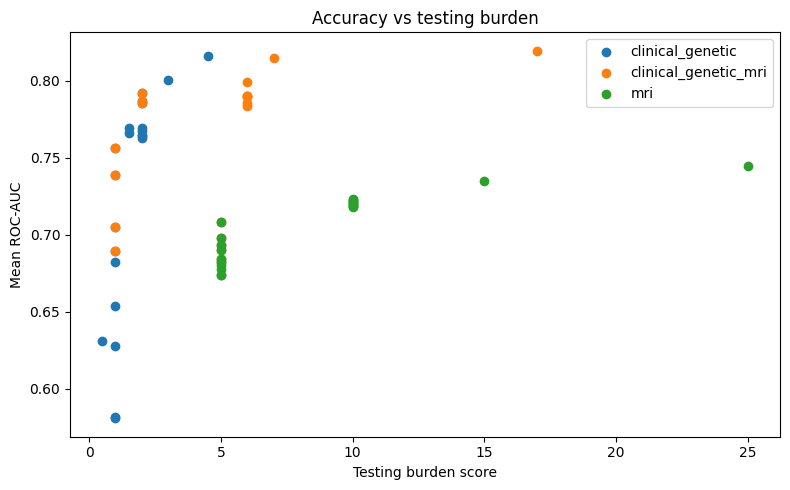

In [84]:
def feature_burden(feature):
    group = classify_feature_group(feature)
    if group == "mri":
        return 5.0
    if group == "blood":
        return 2.0
    if group == "genetic":
        return 0.5
    # Clinical/cognitive:
    cu = feature.upper()
    if any(x in cu for x in ["AGE", "SEX", "GENDER", "EDUC"]):
        return 0.5
    return 1.0

def panel_burden(features_str):
    if pd.isna(features_str) or features_str == "":
        return np.nan
    feats = [f.strip() for f in features_str.split("|")]
    return sum(feature_burden(f) for f in feats)

if not minimal_results.empty:
    minimal_results["burden_score"] = minimal_results["features"].map(panel_burden)
    minimal_results["efficiency_auc_per_burden"] = minimal_results["roc_auc_mean"] / minimal_results["burden_score"]
    minimal_results.to_csv(OUTPUT_DIR / "best_feature_panels.csv", index=False)

    display(minimal_results.sort_values("efficiency_auc_per_burden", ascending=False).head(20))

    plt.figure(figsize=(8, 5))
    for group, g in minimal_results.groupby("feature_group"):
        plt.scatter(g["burden_score"], g["roc_auc_mean"], label=group)
    plt.xlabel("Testing burden score")
    plt.ylabel("Mean ROC-AUC")
    plt.title("Accuracy vs testing burden")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "auc_vs_testing_burden.png", dpi=200)
    plt.show()

## Cell 19 — Ablation analysis for best panels

In [85]:
def ablate_panel(df, features, label):
    rows = []
    full = evaluate_feature_panel(df, features, f"{label}_full")
    if full:
        rows.append({**full, "removed_feature": "none"})

    for f in features:
        reduced = [x for x in features if x != f]
        if len(reduced) == 0:
            continue
        out = evaluate_feature_panel(df, reduced, f"{label}_minus_{f}")
        if out:
            out["removed_feature"] = f
            rows.append(out)

    return pd.DataFrame(rows)

ablation_tables = []
if not minimal_results.empty:
    best_row = minimal_results.sort_values("roc_auc_mean", ascending=False).iloc[0]
    best_features = [f.strip() for f in best_row["features"].split("|")]
    ablation = ablate_panel(model_df, best_features, "best_minimal_panel")
    if not ablation.empty:
        full_auc = ablation.loc[ablation["removed_feature"] == "none", "roc_auc_mean"].iloc[0]
        ablation["auc_drop_vs_full_panel"] = full_auc - ablation["roc_auc_mean"]
        ablation_tables.append(ablation)

ablation_results = pd.concat(ablation_tables, ignore_index=True) if ablation_tables else pd.DataFrame()
ablation_results.to_csv(OUTPUT_DIR / "ablation_results.csv", index=False)
display(ablation_results)

,panel_label,model,n_features,features,roc_auc_mean,roc_auc_std,pr_auc_mean,youden_j_mean,sensitivity_mean,specificity_mean,removed_feature,auc_drop_vs_full_panel
0,best_minimal_panel_full,logistic_l1,5,NEUROBAT__LDELTOTAL | UCSFFSX7__ST99TA | UWNPS...,0.819361,0.019729,0.627292,0.504413,0.732221,0.772193,none,0.000000
1,best_minimal_panel_minus_NEUROBAT__LDELTOTAL,logistic_l1,4,UCSFFSX7__ST99TA | UWNPSYCHSUM__ADNI_MEM | UCS...,0.783858,0.017900,0.592018,0.420693,0.621118,0.799576,NEUROBAT__LDELTOTAL,0.035504
2,best_minimal_panel_minus_UCSFFSX7__ST99TA,logistic_l1,4,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_MEM | ...,0.810016,0.020500,0.605848,0.489973,0.728229,0.761743,UCSFFSX7__ST99TA,0.009346
3,best_minimal_panel_minus_UWNPSYCHSUM__ADNI_MEM,logistic_l1,4,NEUROBAT__LDELTOTAL | UCSFFSX7__ST99TA | UCSFF...,0.802175,0.022607,0.611359,0.489894,0.735849,0.754045,UWNPSYCHSUM__ADNI_MEM,0.017186
4,best_minimal_panel_minus_UCSFFSX7__ST88SV,logistic_l1,4,NEUROBAT__LDELTOTAL | UCSFFSX7__ST99TA | UWNPS...,0.818154,0.020819,0.631342,0.519868,0.739840,0.780027,UCSFFSX7__ST88SV,0.001208
5,best_minimal_panel_minus_UCSFFSX7__ST13TA,logistic_l1,4,NEUROBAT__LDELTOTAL | UCSFFSX7__ST99TA | UWNPS...,0.818300,0.020496,0.625541,0.517326,0.739913,0.777413,UCSFFSX7__ST13TA,0.001061


## Cell 20 — Feature stability summary

,feature,selection_count,group
0,NEUROBAT__LDELTOTAL,24,clinical
1,UCSFFSX7__ST99TA,11,mri
2,UWNPSYCHSUM__ADNI_MEM,10,clinical
19,UCSFFSX7__ST29SV,8,mri
8,UCSFFSX7__ST31TA,5,mri
11,UCSFFSX7__ST40TA,5,mri
10,UCSFFSX7__ST90TA,5,mri
12,UWNPSYCHSUM__ADNI_EF,4,clinical
13,UCSFFSX7__ST52TA,4,mri
7,APOERES__GENOTYPE,4,genetic


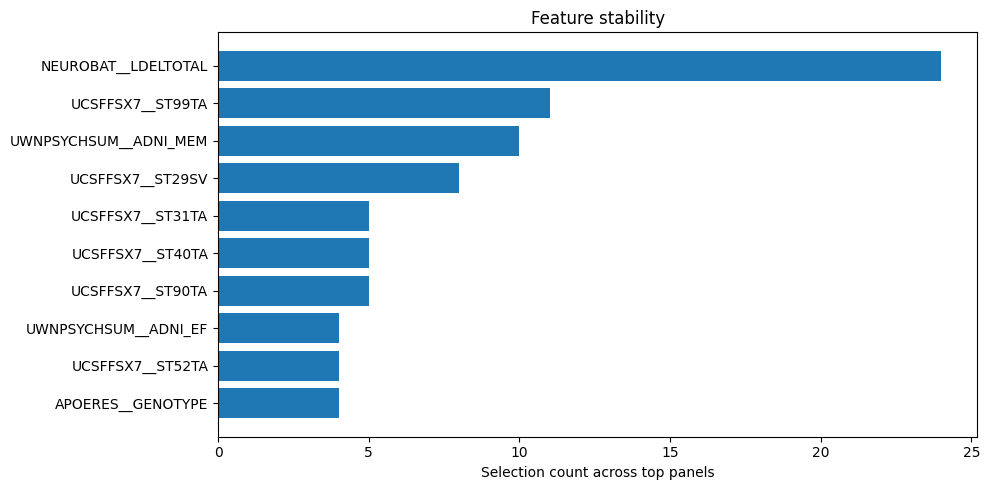

In [86]:
# Stability from minimal-marker results: how often each feature appears in top panels.
if not minimal_results.empty:
    feature_counts = {}
    for _, row in minimal_results.iterrows():
        feats = [f.strip() for f in row["features"].split("|")]
        for f in feats:
            feature_counts[f] = feature_counts.get(f, 0) + 1

    stability = pd.DataFrame([
        {"feature": f, "selection_count": c, "group": classify_feature_group(f)}
        for f, c in feature_counts.items()
    ]).sort_values("selection_count", ascending=False)

    stability.to_csv(OUTPUT_DIR / "feature_stability.csv", index=False)
    display(stability.head(20))

    plt.figure(figsize=(10, 5))
    top = stability.head(10)
    plt.barh(top["feature"][::-1], top["selection_count"][::-1])
    plt.xlabel("Selection count across top panels")
    plt.title("Feature stability")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "feature_stability.png", dpi=200)
    plt.show()

## Cell 21 — ROC curve for best minimal panel

Best panel:
clinical_genetic_mri_forward_5

Features:
- NEUROBAT__LDELTOTAL
- UCSFFSX7__ST99TA
- UWNPSYCHSUM__ADNI_MEM
- UCSFFSX7__ST88SV
- UCSFFSX7__ST13TA


,roc_auc,pr_auc,balanced_accuracy,f1,youden_j,sensitivity,specificity,n_features,features,n_train,n_test,tn,fp,fn,tp
0,0.805739,0.610668,0.75548,0.62069,0.510961,0.692308,0.818653,5,NEUROBAT__LDELTOTAL | UCSFFSX7__ST99TA | UWNPS...,771,258,158,35,20,45


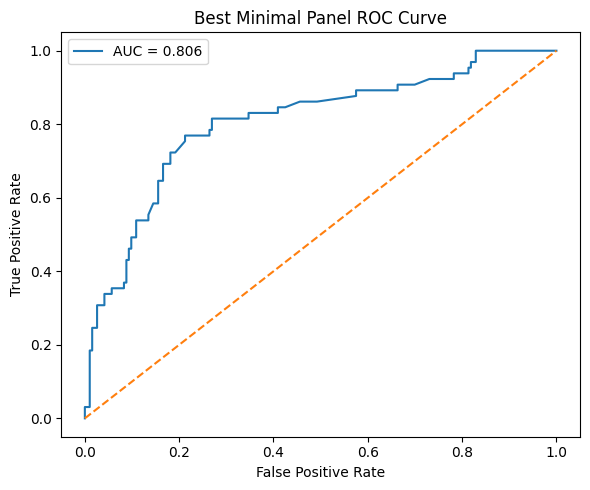

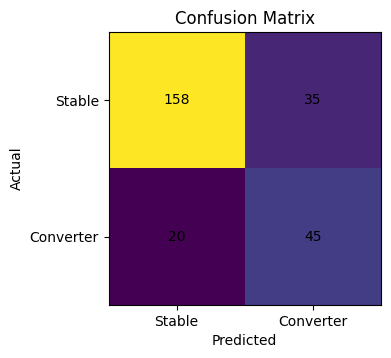

In [88]:
# Cell 21 — Final holdout evaluation for best minimal panel

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    roc_curve
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def final_holdout_eval(df, features, test_size=0.25):
    features = [f for f in features if f in df.columns]

    if len(features) == 0:
        raise ValueError("No valid features were provided.")

    X = df[features].copy()
    y_local = df[TARGET_COL].astype(int)
    groups_local = df["RID"]

    # Patient-level split
    patient_df = (
        pd.DataFrame({
            "RID": groups_local,
            "y": y_local
        })
        .drop_duplicates("RID")
    )

    train_rids, test_rids = train_test_split(
        patient_df["RID"],
        test_size=test_size,
        random_state=42,
        stratify=patient_df["y"] if patient_df["y"].nunique() == 2 else None
    )

    train_mask = df["RID"].isin(train_rids)
    test_mask = df["RID"].isin(test_rids)

    X_train = X.loc[train_mask].copy()
    X_test = X.loc[test_mask].copy()
    y_train = y_local.loc[train_mask].copy()
    y_test = y_local.loc[test_mask].copy()

    pipe = Pipeline(steps=[
        ("preprocess", build_preprocessor(X_train)),
        ("model", make_l1_model())
    ])

    pipe.fit(X_train, y_train)

    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    youden_j = sensitivity + specificity - 1

    metrics = {
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "youden_j": youden_j,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "n_features": len(features),
        "features": " | ".join(features),
        "n_train": len(y_train),
        "n_test": len(y_test),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    return pipe, X_test, y_test, y_prob, y_pred, metrics


if not minimal_results.empty:
    best_row = minimal_results.sort_values("roc_auc_mean", ascending=False).iloc[0]
    best_features = [f.strip() for f in best_row["features"].split("|")]

    print("Best panel:")
    print(best_row["panel_label"])
    print("\nFeatures:")
    for f in best_features:
        print("-", f)

    pipe, X_test, y_test, y_prob, y_pred, final_metrics = final_holdout_eval(
        df=model_df,
        features=best_features,
        test_size=0.25
    )

    final_metrics_df = pd.DataFrame([final_metrics])
    display(final_metrics_df)

    final_metrics_df.to_csv(OUTPUT_DIR / "final_test_results.csv", index=False)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {final_metrics['roc_auc']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Best Minimal Panel ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "best_minimal_roc.png", dpi=200)
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    plt.figure(figsize=(4, 4))
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.xticks([0, 1], ["Stable", "Converter"])
    plt.yticks([0, 1], ["Stable", "Converter"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "best_minimal_confusion_matrix.png", dpi=200)
    plt.show()

else:
    print("minimal_results is empty. Run Cell 17 first.")

## Cell 22 — Final interpretation helper

In [89]:
def summarize_final_findings():
    print("FINAL QUESTIONS TO ANSWER")
    print("1. What is the best single marker?")
    print("2. What is the best 2-marker panel?")
    print("3. What is the best 3-marker panel?")
    print("4. What is the best 5-marker panel?")
    print("5. How close do minimal panels get to the full multimodal model?")
    print("6. Does MRI add value beyond clinical/cognitive tests?")
    print("7. Does a small clinical panel outperform MRI alone?")
    print("8. Which features are stable across folds?")
    print("9. What is the best accuracy-versus-testing-burden tradeoff?")
    print("10. Can these features predict 2-year MCI-to-dementia progression?")

    if not minimal_results.empty:
        print("\nTop minimal panels by ROC-AUC:")
        display(minimal_results.sort_values("roc_auc_mean", ascending=False).head(10))

        print("\nTop minimal panels by efficiency:")
        display(minimal_results.sort_values("efficiency_auc_per_burden", ascending=False).head(10))

summarize_final_findings()

FINAL QUESTIONS TO ANSWER
1. What is the best single marker?
2. What is the best 2-marker panel?
3. What is the best 3-marker panel?
4. What is the best 5-marker panel?
5. How close do minimal panels get to the full multimodal model?
6. Does MRI add value beyond clinical/cognitive tests?
7. Does a small clinical panel outperform MRI alone?
8. Which features are stable across folds?
9. What is the best accuracy-versus-testing-burden tradeoff?
10. Can these features predict 2-year MCI-to-dementia progression?

Top minimal panels by ROC-AUC:


,panel_label,model,n_features,features,roc_auc_mean,roc_auc_std,pr_auc_mean,youden_j_mean,sensitivity_mean,specificity_mean,added_feature,feature_group,burden_score,efficiency_auc_per_burden
65,clinical_genetic_mri_forward_5,logistic_l1,5,NEUROBAT__LDELTOTAL | UCSFFSX7__ST99TA | UWNPS...,0.819361,0.019729,0.627292,0.504413,0.732221,0.772193,UCSFFSX7__ST13TA,clinical_genetic_mri,17.0,0.048198
21,clinical_genetic_forward_5,logistic_l1,5,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_MEM | ...,0.815647,0.021173,0.627894,0.484195,0.743324,0.740871,APOERES__GENOTYPE,clinical_genetic,4.5,0.181255
64,clinical_genetic_mri_forward_3,logistic_l1,3,NEUROBAT__LDELTOTAL | UCSFFSX7__ST99TA | UWNPS...,0.814900,0.020786,0.628473,0.519856,0.743759,0.776097,UWNPSYCHSUM__ADNI_MEM,clinical_genetic_mri,7.0,0.116414
20,clinical_genetic_forward_3,logistic_l1,3,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_MEM | ...,0.800189,0.017615,0.592933,0.478814,0.762627,0.716187,GDSCALE__GDHOME,clinical_genetic,3.0,0.266730
54,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UCSFFSX7__ST99TA,0.799252,0.025854,0.602354,0.492460,0.743687,0.748773,NaN,clinical_genetic_mri,6.0,0.133209
10,clinical_genetic_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_MEM,0.792197,0.020164,0.579156,0.494432,0.762627,0.731805,NaN,clinical_genetic,2.0,0.396099
55,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UWNPSYCHSUM__ADNI_MEM,0.792197,0.020164,0.579156,0.494432,0.762627,0.731805,NaN,clinical_genetic_mri,2.0,0.396099
56,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UCSFFSX7__ST31TA,0.790039,0.029465,0.597124,0.474370,0.735994,0.738375,NaN,clinical_genetic_mri,6.0,0.131673
57,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UCSFFSX7__ST118TA,0.789792,0.029547,0.586569,0.454768,0.732003,0.722765,NaN,clinical_genetic_mri,6.0,0.131632
58,clinical_genetic_mri_top2,logistic_l1,2,NEUROBAT__LDELTOTAL | UCSFFSX7__ST90TA,0.789738,0.037993,0.592338,0.459983,0.728084,0.731899,NaN,clinical_genetic_mri,6.0,0.131623



Top minimal panels by efficiency:


,panel_label,model,n_features,features,roc_auc_mean,roc_auc_std,pr_auc_mean,youden_j_mean,sensitivity_mean,specificity_mean,added_feature,feature_group,burden_score,efficiency_auc_per_burden
6,clinical_genetic_top1,logistic_l1,1,APOERES__GENOTYPE,0.631229,0.024125,0.329158,0.251070,0.662554,0.588515,NaN,clinical_genetic,0.5,1.262459
44,clinical_genetic_mri_top1,logistic_l1,1,NEUROBAT__LDELTOTAL,0.756262,0.026621,0.501717,0.395028,0.716546,0.678482,NaN,clinical_genetic_mri,1.0,0.756262
0,clinical_genetic_top1,logistic_l1,1,NEUROBAT__LDELTOTAL,0.756262,0.026621,0.501717,0.395028,0.716546,0.678482,NaN,clinical_genetic,1.0,0.756262
1,clinical_genetic_top1,logistic_l1,1,UWNPSYCHSUM__ADNI_MEM,0.738439,0.018644,0.527039,0.331623,0.559507,0.772116,NaN,clinical_genetic,1.0,0.738439
45,clinical_genetic_mri_top1,logistic_l1,1,UWNPSYCHSUM__ADNI_MEM,0.738439,0.018644,0.527039,0.331623,0.559507,0.772116,NaN,clinical_genetic_mri,1.0,0.738439
47,clinical_genetic_mri_top1,logistic_l1,1,NEUROBAT__LIMMTOTAL,0.704962,0.019412,0.478432,0.307120,0.682003,0.625117,NaN,clinical_genetic_mri,1.0,0.704962
2,clinical_genetic_top1,logistic_l1,1,NEUROBAT__LIMMTOTAL,0.704962,0.019412,0.478432,0.307120,0.682003,0.625117,NaN,clinical_genetic,1.0,0.704962
51,clinical_genetic_mri_top1,logistic_l1,1,UWNPSYCHSUM__ADNI_EF,0.689639,0.034690,0.463592,0.237520,0.501887,0.735634,NaN,clinical_genetic_mri,1.0,0.689639
3,clinical_genetic_top1,logistic_l1,1,UWNPSYCHSUM__ADNI_EF,0.689639,0.034690,0.463592,0.237520,0.501887,0.735634,NaN,clinical_genetic,1.0,0.689639
4,clinical_genetic_top1,logistic_l1,1,UWNPSYCHSUM__ADNI_EF2,0.682145,0.036913,0.456412,0.236292,0.494122,0.742170,NaN,clinical_genetic,1.0,0.682145
